In [15]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [16]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("medical_insurance_cost.csv")

print(df.shape)
print(df.head())
print(df.dtypes)

(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [17]:
print(df.isnull().sum())
print()
print(df.describe())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


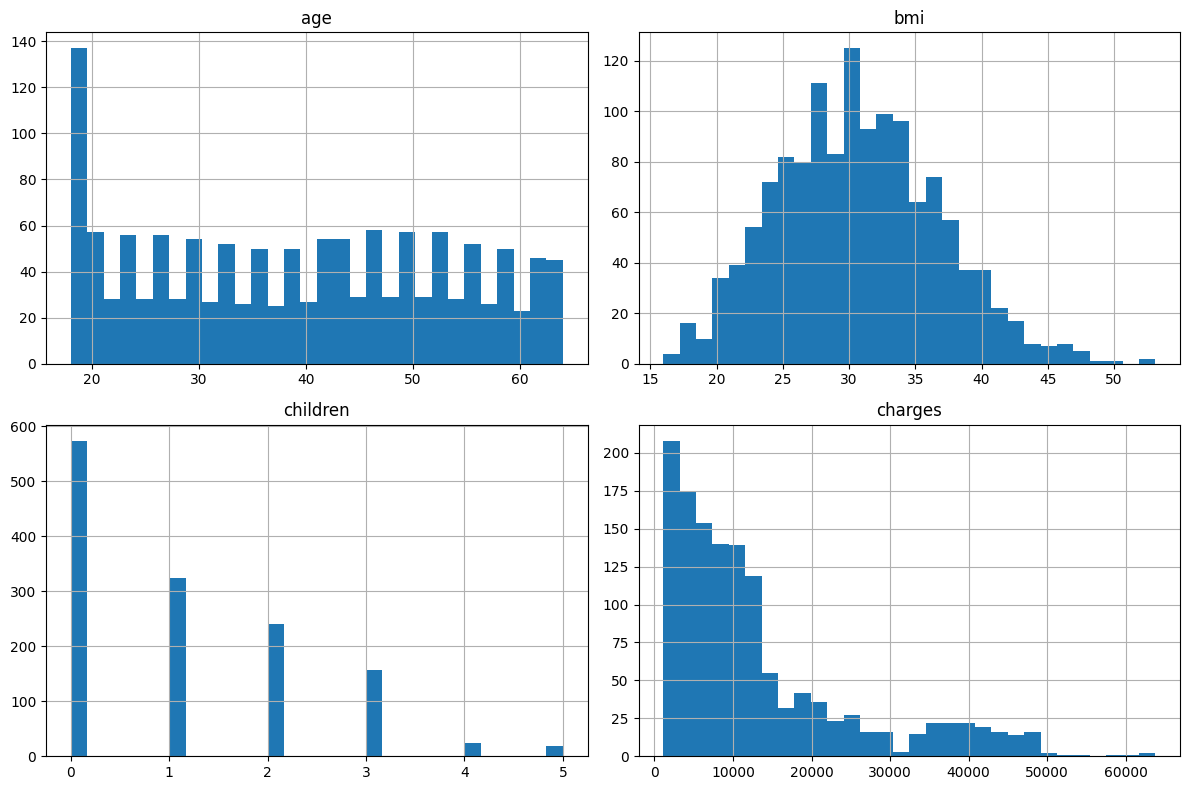

In [18]:
df[["age", "bmi", "children", "charges"]].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

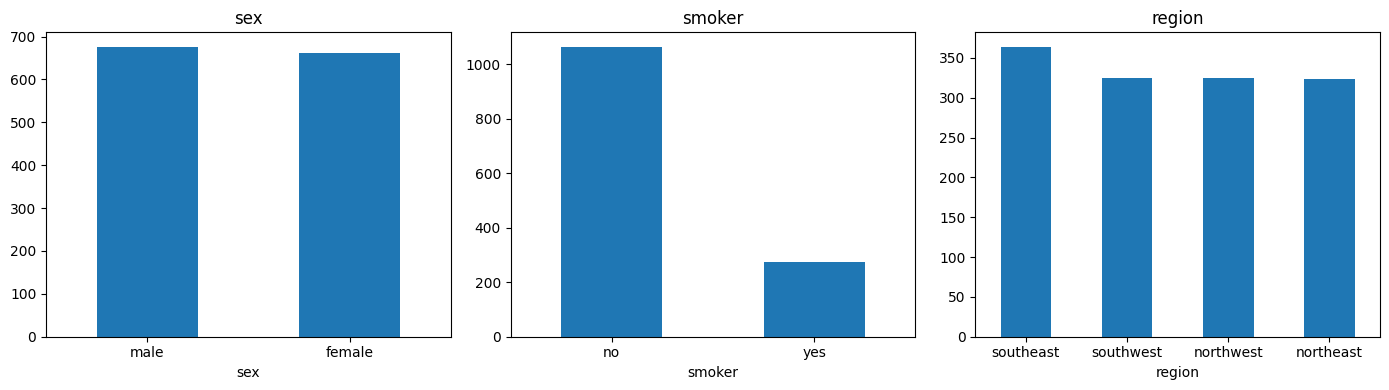

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["sex", "smoker", "region"]):
    df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

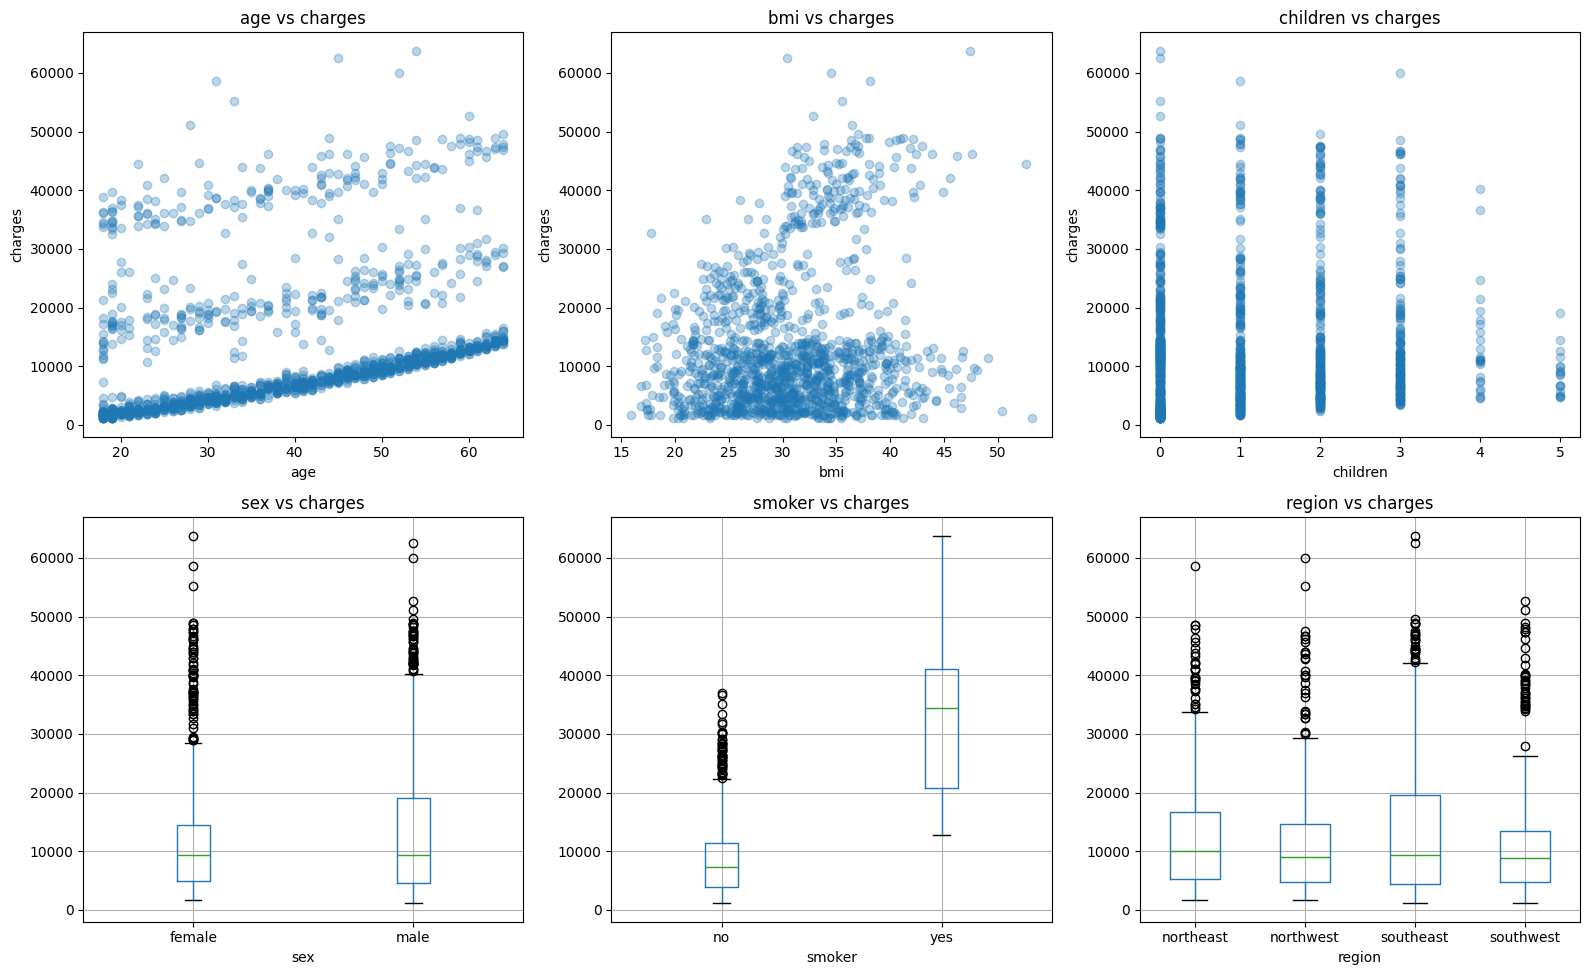

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

num_cols = ["age", "bmi", "children"]
cat_cols = ["sex", "smoker", "region"]

for ax, col in zip(axes[0], num_cols):
    ax.scatter(df[col], df["charges"], alpha=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel("charges")
    ax.set_title(f"{col} vs charges")

for ax, col in zip(axes[1], cat_cols):
    df.boxplot(column="charges", by=col, ax=ax)
    ax.set_title(f"{col} vs charges")
    ax.set_xlabel(col)

plt.suptitle("")
plt.tight_layout()
plt.show()

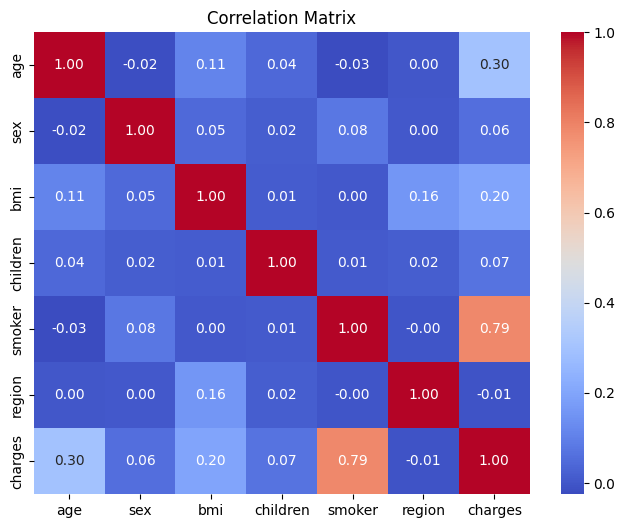

In [21]:
df_encoded = df.copy()
df_encoded["sex"] = LabelEncoder().fit_transform(df["sex"])
df_encoded["smoker"] = LabelEncoder().fit_transform(df["smoker"])
df_encoded["region"] = LabelEncoder().fit_transform(df["region"])

plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Feature Selection Decision

Based on EDA findings:

| Feature | Correlation with charges | Decision |
|---------|--------------------------|----------|
| smoker | 0.79 | Keep |
| age | 0.30 | Keep |
| bmi | 0.20 | Keep |
| children | 0.07 | Keep (borderline, will evaluate post-model) |
| sex | 0.06 | Drop — no meaningful signal |
| region | -0.01 | Drop — no meaningful signal |

Dropping columns only — all 1338 rows retained.

In [22]:
df_model = df.drop(columns=["sex", "region"])

print(df_model.shape)
print(df_model.head())

(1338, 5)
   age     bmi  children smoker      charges
0   19  27.900         0    yes  16884.92400
1   18  33.770         1     no   1725.55230
2   28  33.000         3     no   4449.46200
3   33  22.705         0     no  21984.47061
4   32  28.880         0     no   3866.85520


## Encoding

`smoker` is binary (yes/no) so we use LabelEncoder — it becomes 0/1.
No other categorical columns remain after feature selection.

In [23]:
df_model["smoker"] = LabelEncoder().fit_transform(df_model["smoker"])

X  = df_model.drop(columns=["charges"])
y = df_model["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(1070, 4) (268, 4)


## Step 3: Linear Regression Model (Default)

Training a baseline LinearRegression model with no hyperparameter tuning.
Metrics used:
- R² (coefficient of determination): how much variance the model explains
- RMSE (root mean squared error): average prediction error in dollars

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2:    {r2:.4f}")
print(f"RMSE    {rmse:.2f}")

R^2:    0.7811
RMSE    5829.38


## Prediction Visualization

Plotting actual vs predicted charges to visually assess model performance.
A perfect model would have all points on the diagonal line.

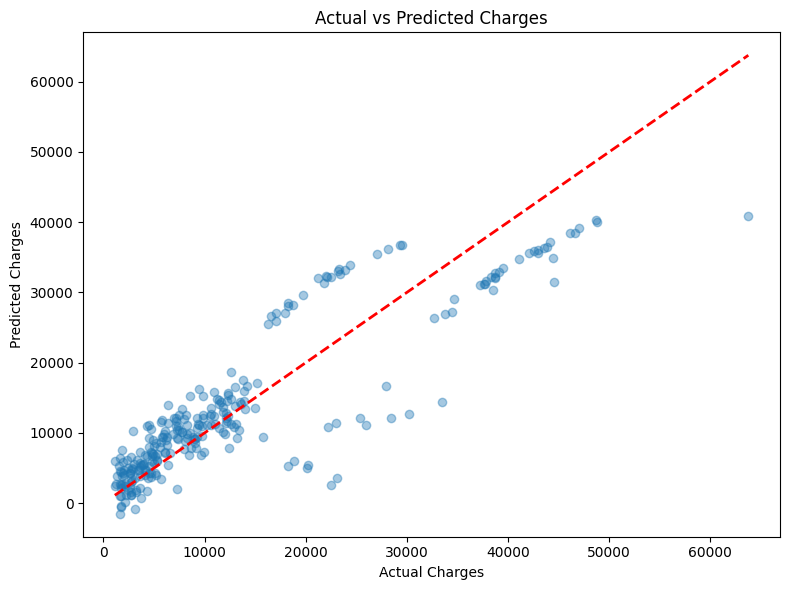

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.tight_layout()
plt.show()

## Step 4: Model Optimization

The baseline model (R² 0.78, RMSE $5829) shows two distinct prediction clusters,
indicating the model cannot capture the interaction between smoker and other variables.

Strategy: engineer interaction features that explicitly represent known relationships:
- smoker × bmi: captures the compounding cost of smoking + obesity
- smoker × age: captures the compounding cost of smoking + age

In [26]:
df_optimized = df_model.copy()

df_optimized["smoker_bmi"] = df_optimized["smoker"] * df_optimized["bmi"]
df_optimized["smoker_age"] = df_optimized["smoker"] * df_optimized["age"]

X2 = df_optimized.drop(columns=["charges"])
y2 = df_optimized["charges"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print(X2_train.shape, X2_test.shape)

(1070, 6) (268, 6)


In [27]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

r2_2 = r2_score(y2_test, y2_pred)
rmse_2 = np.sqrt(mean_squared_error(y2_test, y2_pred))

print(f"R^2:    {r2_2:.4f}")
print(f"RMSE:   {rmse_2:.2f}")
print()
print(f"R^2 improvement:    {r2_2 - r2:.4f}")
print(f"RMSE improvement: {rmse - rmse_2:.2f}")

R^2:    0.8628
RMSE:   4614.84

R^2 improvement:    0.0817
RMSE improvement: 1214.54


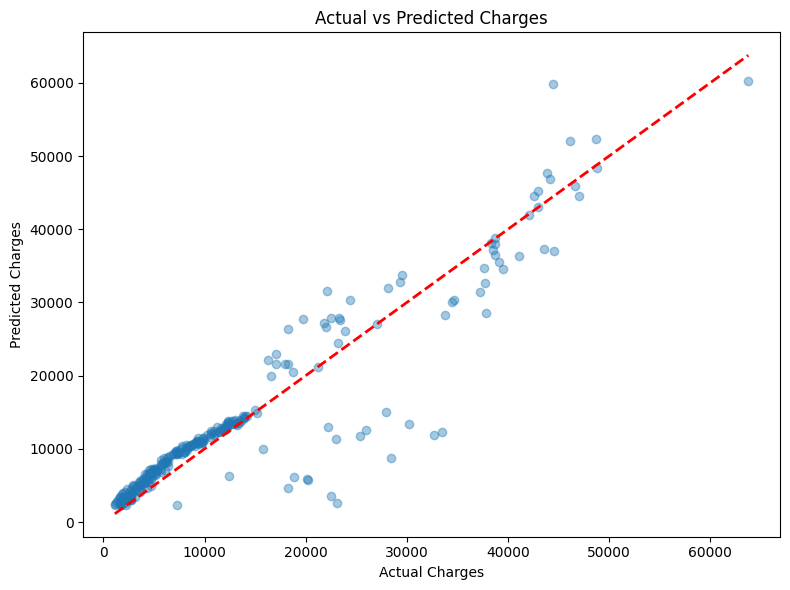

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(y2_test, y2_pred, alpha=0.4)
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], "r--", linewidth=2)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.tight_layout()
plt.show()

## Results Summary

| Metric | Baseline | Optimized | Improvement |
|--------|----------|-----------|-------------|
| R²     | 0.7811   | 0.8628    | +0.0817     |
| RMSE   | $5829.38 | $4614.84  | -$1214.54   |

Optimization method: interaction feature engineering (smoker×bmi, smoker×age)
No hyperparameter tuning required — improvement came entirely from better feature representation.

Key finding: smoking is the dominant cost driver (correlation 0.79),
but its true impact is multiplicative with bmi and age, not additive.
A plain linear model cannot capture this without explicit interaction terms.